# はじめに

今回は、中日スポーツが公開しているボートレースの展開に関するベイズモデリングの記事を参考にして「展開」への理解を深める。

- [連動する不確実性 「展開」の正体競艇の統計的モデリング2024](https://static.chunichi.co.jp/chuspo/pages/feature/kyotei/statistical_structure_of_uncertainties_in_boat_races.html)

## モデルの内容

中日スポーツの記事では、順位を決める「強さ」が下記の要素の合計で決まることを想定している。

- 強さ = 選手の力 + 進入コースの力 + 選手別進入コースの力 + モーターの力 + F2 + 運(多変量正規分布)

手元のPCのスペックの都合もあり、中日スポーツのモデルをもとに3年間のデータをもとにサンプリングを試みたが、1時間で全体の1~2%くらいしか終わらず断念した(途中で落ちる、または60h時間前後かかる見込み…)。そのため、下記の通り、モデルは最小限の構成で、計算期間も24年12月のレースのみとしている。

- 強さ = 選手の力 + 枠の力 + 運(多変量正規分布)

ここでの目的は正確な分析よりも多変量正規分布が再現する「展開」の表現の仕方なので、結果的にこれで十分とした（試すにも時間がかかりすぎ、試すに試せていない）。また、中日スポーツのモデルが着順(順序)をどのように扱っているのかわからなかった。[個人の方のブログ](https://strawberry-kyon.hateblo.jp/entry/2017/10/05/031844)では下記のように扱っているケースもある。

```
Performance[g,r]∼Normal(μn[n[g,r]]+μc[c[g,r]],σp)
Performance[g,1]>Performance[g,2]>,...,>Performance[g,6]
```

どれが正しいとか、間違いとかは特にないと思う。順位の起こり方をいろんな仮説をもとに柔軟にモデリングできるのがベイズモデリングの良さでもあると思う。

今回使用したstanモデルは下記の通り。サンプリング処理を軽くするために`reduce_sum`関数を利用している。とくに計算の順番が結果が変わることもないと思うので、並列化した結果を足し合わせることで推定した。分割してレース単位で計算、それを足し合わせるというイメージ。

In [ ]:
functions {
  real partial_log_lik(
    array[] int race_slice,
    int start,
    int end,

    int N_teiban,
    array[,] int player_id,
    array[,] int lane_id,
    array[,] int rank,

    vector alpha,
    vector beta,
    vector sigma_u,
    matrix L_Omega,
    matrix z_u
  ) {
    real lp = 0;
    // reduce_sum により割り当てられた「race_slice の start:end 区間」だけを処理する
    for (i in start:end) {
      // レースの行インデックス（ここでは race_index = 1..N_races を渡しているので、単なる r 番目レース）
      int r = race_slice[i];
    
      vector[N_teiban] eta_all;
      row_vector[N_teiban] u_r_row;

      // レース r に固有の「レーン別ランダム効果」 u_r（非中心化：diag(sigma_u) * L_Omega * z_r）
      // u_r は N_teiban 次元で、レーン間に相関（L_Omega）とスケール（sigma_u）を持つ
      u_r_row = (diag_pre_multiply(sigma_u, L_Omega) * (z_u[r]'))';

      // 各出走スロット boat (=艇/枠) の線形予測子 eta_all[boat] を計算
      // eta_all[boat] = 選手効果 alpha[player_id] + レーン固定効果 beta[lane_id] + レース固有レーン効果 u_r[lane_id]
      for (boat in 1:N_teiban) {
        int pid = player_id[r, boat];
        int lid = lane_id[r, boat];
        eta_all[boat] = alpha[pid] + beta[lid] + u_r_row[lid];
      }

      {
        vector[N_teiban] eta;
        // 観測された順位 rank[r, k] に従って、線形予測子を「1着,2着,...」の順に並べ替える
        for (k in 1:N_teiban) {
          int boat = rank[r, k];
          eta[k] = eta_all[boat];
        }
        // Plackett–Luce の対数尤度
        for (k in 1:N_teiban) {
          lp += eta[k] - log_sum_exp(eta[k:N_teiban]);
        }
      }
    }
    return lp;
  }
}


data {
  int<lower=1> N_races;
  int<lower=1> N_teiban;
  int<lower=1> N_players;

  array[N_races, N_teiban] int player_id;
  array[N_races, N_teiban] int lane_id;
  array[N_races, N_teiban] int rank;
}

parameters {
  vector[N_players] alpha_raw;
  vector[N_teiban] beta_raw;

  real<lower=1e-6> sigma_alpha;
  real<lower=1e-6> sigma_beta;

  vector<lower=1e-6>[N_teiban] sigma_u;
  cholesky_factor_corr[N_teiban] L_Omega;
  matrix[N_races, N_teiban] z_u;
}

transformed parameters {
  // 位置の不識別性を避けるため、alpha と beta を平均0に中心化（和=0制約に相当）
  vector[N_players] alpha = alpha_raw - mean(alpha_raw);
  vector[N_teiban] beta = beta_raw - mean(beta_raw);
}

model {
  // priors
  sigma_alpha ~ exponential(1);
  sigma_beta  ~ exponential(1);
  sigma_u     ~ exponential(1);

  alpha_raw ~ normal(0, sigma_alpha);
  beta_raw  ~ normal(0, sigma_beta);
  L_Omega   ~ lkj_corr_cholesky(4);
  to_vector(z_u) ~ std_normal();

  // race index (1..N_races)
  {
    array[N_races] int race_index;
    for (i in 1:N_races) race_index[i] = i;

    target += reduce_sum(
      partial_log_lik,
      race_index,
      50,
      N_teiban,
      player_id,
      lane_id,
      rank,
      alpha,
      beta,
      sigma_u,
      L_Omega,
      z_u
    );
  }
}

generated quantities {
  // コレスキー因子から相関行列を復元
  corr_matrix[N_teiban] Omega = multiply_lower_tri_self_transpose(L_Omega);
}


## 「展開」の表現方法

このモデルでは、「どの艇同士が一連動して上下するか」を「展開」として表現しようと試みている。実際の展開はもっと複雑かもしれないが、ここでは艇ごとの動きによって、他の艇も連動する点を展開とする。なぜこれで表現できそうなのかを忘れないようにまとめておく。

ここでは簡略化して3艇構成とする。レース$r$ごとに展開ベクトルを考える。各要素は、連動し、同じレース内では、これらは同時に決まるとする。

$$
u_{r} = (u_{r,1}, u_{r,2}, u_{r,3})^{T}
$$

分布の仮定として、多変量正規分布を考える。

$$
u_{r} \sim N(0, \Sigma_{u})
$$

分散共分散行列は

$$
\Sigma_{u} = D \Omega D
$$

と分解する。$D$は各コースの荒れやすさを表す。ボートレースのセオリーはインコース有利のイン逃げなので、1コースは展開のブレが小さい=荒れない、というイメージ。感覚的には、レースごとにこのコースは“想定外の上振れ・下振れ”がどれくらい起きるか。競艇文脈で考えるのであれば、「このコースはレースによって主役にも事故源にもなる」のであれば$\sigma_{u}$が大きく、「このコースは毎回だいたい役割が固定」されているのであれば$\sigma_{u}$が小さい。

$$
D = diag(\sigma_{u,1}=0.2, \sigma_{u,2}=0.4, \sigma_{u,3}=0.6)
$$

次に相関を考える。レーンが相関しないのであれば、独立となるが、ボートレースはそうではない。

$$
\Omega =
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

実際は2コースが先マイして成功すれば、3コースは行き場を失って着が低くなり、2コースと3コースの着順は連動して下がる。逆も然りで、3コースがまくりに成功すれば、2コースは抵抗に失敗することになる。

$$
\Omega =
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & -0.6 \\
0 & -0.6 & 1
\end{pmatrix}
$$

各コースの荒れやすさ$D$と連動関係$\Omega$を組み合わせることで、展開を表現する。実際に計算すると、このような分散共分散行列ができる。

$$
\Sigma_u
=
D\Omega D
=
\begin{pmatrix}
0.2 & 0   & 0   \\
0   & 0.4 & 0   \\
0   & 0   & 0.6
\end{pmatrix}
\begin{pmatrix}
1   & 0   & 0   \\
0   & 1   & -0.6 \\
0   & -0.6 & 1
\end{pmatrix}
\begin{pmatrix}
0.2 & 0   & 0   \\
0   & 0.4 & 0   \\
0   & 0   & 0.6
\end{pmatrix}
=
\begin{pmatrix}
0.04 & 0     & 0      \\
0    & 0.16  & -0.144 \\
0    & -0.144 & 0.36
\end{pmatrix}
$$


Stanでは`sigma_u`を$D = diag(\sigma_{u,1}, \sigma_{u,2}, \sigma_{u,3})$、$\Omega$のコレスキー分解を$L_{\Omega}$($\Omega=L_{\Omega} L_{\Omega}^{T}$)、$z_{u} = (z_{r,1},z_{r,2},z_{r,3})^{T}$は標準正規分布として対応させている。

$$
u_{r} = D L_{\Omega} z_{r}, z_{r} \sim N(0, I)
$$

```
to_vector(z_u) ~ std_normal();

u_r = diag_pre_multiply(sigma_u, L_Omega) * z_u[r]';
```

再掲となるが

$$
\sigma_{u} = (0.2, 0.4, 0.6)
$$

$$
\Omega =
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & -0.6 \\
0 & -0.6 & 1
\end{pmatrix}
$$

コレスキー分解を計算すると

$$
L_{\Omega} \approx
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -0.6 & \sqrt{1-0.6^2}
\end{pmatrix}
=
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -0.6 & 0.8
\end{pmatrix}
$$

である。Stanでは標準正規分布からサンプリングするとして(`sto_vector(z_u) ~ std_normal();`)

$$
z_{r} = (0.5, -1.0, 0.3)
$$

`u_r_row = (diag_pre_multiply(sigma_u, L_Omega) * (z_u[r]'))';`は

$$
u_{r} = 
DL_{\Omega}(z_{r}) =
\begin{pmatrix}
0.2 & 0 & 0 \\
0 & 0.4 & 0 \\
0 & 0 & 0.6
\end{pmatrix}
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & -0.6 & 0.8
\end{pmatrix}
\begin{pmatrix}
0.5  \\
-1.0  \\
0.3 
\end{pmatrix}
=
\begin{pmatrix}
0.10  \\
-0.40  \\
0.504
\end{pmatrix}
$$

このように計算される。

$$
u_{r} = 
DL_{\Omega}(z_{r}) =
\begin{pmatrix}
+0.10  \\
-0.40  \\
+0.504
\end{pmatrix}
$$

明示的にプラス記号を追加している。2コースが下がれば、3コースが上がるという関係が同時に発生している。つまり、2コースと3コースの着順は連動して下がる。逆も然りで、展開を表現するベクトルができたので、これを強さに加えることで、ボートレース的には3コースがまくりに行って成功し、2コースは抵抗して失敗、ターンが流れる、1コースはほぼ影響なしという展開を表現できる。「展開」は、「独立したノイズ$z$」に「コース固有の荒れやすさ$D$」を「コース間の連動構造$\Omega$」同時に注入したもの、そんなイメージで表現した。そもそも適切にやりたいことを表現できているかはわからないが。

以降は計算のためのPythonコードである。収束が怪しいので、仮に収束していれば、という解釈で進めている点は注意。勉強ノートなので一旦はスルーする。もっとchains × iter を増やすか、事前分布を調整するなどで解消できそうだが、兎にも角にもサンプリング時間がかかりすぎるので。

また、今回は選手、枠、展開というシンプルなモデルなので、そもそも実態をうまく表現できているかを検証してない。中日スポーツのモデル構成を再現すれば、

- 強さ = 選手の力 + 進入コースの力 + 選手別進入コースの力 + モーターの力 + F2 + 運(多変量正規分布)

もっと世間一般で言われているような事象も説明できるかも。ただ、F以外のデータは用意できそうではあるが、Fは公式の番号表をスクレイピングしないと手元にないので、またいつの日か試す。

### 展開の分析

In [1]:
import json
import numpy as np
import polars as pl
from cmdstanpy import CmdStanModel
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# .filter(pl.col("RaceId").str.slice(0, 6).is_in([f"2024{m:02d}" for m in range(7, 13)]))\
df = (
    pl.read_csv("./results.csv")
    .select(["RaceId", "Teiban", "PlayerNo", "Rank"])
    .filter(pl.col("RaceId").str.slice(0, 6) == "202412")
    .sort(["RaceId", "Teiban"], descending=[False, False])
)

# df\
#     .group_by("RaceId")\
#     .agg(
#         pl.len().alias("count"),
#         pl.col("Rank").sum().alias("rank_sum")
#     )\
#     .filter(
#         (pl.col("count") != 6) | (pl.col("rank_sum") != 21)
#     )
df.head(12)

RaceId,Teiban,PlayerNo,Rank
str,i64,i64,i64
"""20241201_02_01""",1,3507,3
"""20241201_02_01""",2,5256,1
"""20241201_02_01""",3,5073,5
"""20241201_02_01""",4,4789,2
"""20241201_02_01""",5,5065,6
…,…,…,…
"""20241201_02_02""",2,3385,2
"""20241201_02_02""",3,4049,4
"""20241201_02_02""",4,5152,5


Stanでは、そのまま選手番号を扱えないので、1始まりの番号を再度付与する。

In [4]:
pl.Config.set_tbl_rows(-1)
# PlayerNoを1から始まる連番にマッピング
players = (
    df.select("PlayerNo")
    .unique()
    .sort("PlayerNo")
    .with_row_index("player_index", offset=1)
)
df = df.join(players, on="PlayerNo", how="left")
df.head(18)

RaceId,Teiban,PlayerNo,Rank,player_index
str,i64,i64,i64,u32
"""20241201_02_01""",1,3507,3,109
"""20241201_02_01""",2,5256,1,1379
"""20241201_02_01""",3,5073,5,1227
"""20241201_02_01""",4,4789,2,1016
"""20241201_02_01""",5,5065,6,1220
"""20241201_02_01""",6,5315,4,1431
"""20241201_02_02""",1,5095,1,1245
"""20241201_02_02""",2,3385,2,64
"""20241201_02_02""",3,4049,4,436


Stanに渡すためのデータを準備する。

In [5]:
race_id_list = df.select("RaceId").unique(maintain_order=True).to_series().to_list()
N_races = len(race_id_list)
N_teiban = 6
N_players = len(players)

# 初期化
player_id = np.zeros((N_races, N_teiban), dtype=int)
lane_id = np.zeros((N_races, N_teiban), dtype=int)
rank_arr = np.zeros((N_races, N_teiban), dtype=int)

Stanでの計算方法に合わせて、レースごとにリストを作成する。

In [ ]:
for r_idx, rid in enumerate(race_id_list):
    dr_boat = df.filter(pl.col("RaceId") == rid).sort(
        "Teiban"
    )  # Teiban順でソートして順番を揃える

    player_id[r_idx, :] = dr_boat["player_index"].to_numpy()
    lane_id[r_idx, :] = dr_boat["Teiban"].to_numpy()
    rank_arr[r_idx, :] = dr_boat["Rank"].to_numpy()

data = {
    "N_races": N_races,
    "N_teiban": N_teiban,
    "N_players": N_players,
    "player_id": player_id,
    "lane_id": lane_id,
    "rank": rank_arr,
}

In [11]:
data

{'N_races': 4363,
 'N_teiban': 6,
 'N_players': 1505,
 'player_id': array([[ 109, 1379, 1227, 1016, 1220, 1431],
        [1245,   64,  436, 1292,  500,  338],
        [ 557,  680,   70,  932,   18,  628],
        ...,
        [ 320, 1088,  805, 1402,  375, 1177],
        [ 756,  418,  474,  599,  241,  963],
        [ 638,  990,  651, 1423, 1070,  492]], shape=(4363, 6)),
 'lane_id': array([[1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        ...,
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6]], shape=(4363, 6)),
 'rank': array([[3, 1, 5, 2, 6, 4],
        [1, 2, 4, 5, 3, 6],
        [1, 3, 2, 4, 6, 5],
        ...,
        [1, 2, 3, 5, 6, 4],
        [1, 2, 3, 5, 6, 4],
        [3, 2, 1, 5, 4, 6]], shape=(4363, 6))}

モデルをコンパイルしておく。

In [ ]:
model = CmdStanModel(stan_file="./plackett_luce_model.stan")

サンプリングを高速化するために初期値を与えておく。

In [ ]:
init_dict = {
    "sigma_alpha": 1.0,
    "sigma_beta": 1.0,
    "sigma_u": np.repeat(0.3, N_teiban),
    "L_Omega": np.eye(N_teiban),
    "alpha_raw": np.zeros(N_players),
    "beta_raw": np.zeros(N_teiban),
    "z_u": np.zeros((N_races, N_teiban)),
}

サンプリングを実行したが、並列化しているので結局3.5時間とはいえ、このサイズで1チェインで約3時間要している。

In [ ]:
fit = model.sample(
    data=data,
    chains=4,
    parallel_chains=4,
    threads_per_chain=4,
    iter_warmup=1000,
    iter_sampling=6000,
    seed=123,
    adapt_delta=0.8,
    inits=init_dict,
)

00:32:12 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

04:04:26 - cmdstanpy - INFO - CmdStan done processing.
04:04:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lkj_corr_cholesky_lpdf: Random variable[2] is 0, but must be positive! (in 'plackett_luce_model.stan', line 93, column 2 to column 35)
Exception: lkj_corr_cholesky_lpdf: Random variable[3] is 0, but must be positive! (in 'plackett_luce_model.stan', line 93, column 2 to column 35)
Exception: lkj_corr_cholesky_lpdf: Random variable[2] is 0, but must be positive! (in 'plackett_luce_model.stan', line 93, column 2 to column 35)
Exception: lkj_corr_cholesky_lpdf: Random variable[2] is 0, but must be positive! (in 'plackett_luce_model.stan', line 93, column 2 to column 35)
Consider re-running with show_console=True if the above output is unclear!


1コースはイン逃げも逃げ失敗も、「展開を作る／壊すコース」なので大きいことがわかる。

In [ ]:
import warnings

warnings.filterwarnings("ignore", message="invalid value encountered")
# az.summary(fit, var_names=["sigma_u", "Omega", "beta", "sigma_alpha", "sigma_beta"], round_to=2)
az.summary(fit, var_names=["sigma_u"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_u[0],3.27,0.53,2.35,4.28,0.10,0.03,29.10,138.13,1.11
sigma_u[1],2.14,0.42,1.42,2.98,0.07,0.02,34.36,352.57,1.10
sigma_u[2],2.14,0.49,1.22,3.10,0.09,0.03,32.18,157.82,1.10
sigma_u[3],2.32,0.55,1.39,3.34,0.11,0.04,25.14,139.93,1.19
sigma_u[4],2.29,0.49,1.41,3.23,0.09,0.03,31.33,112.98,1.09
sigma_u[5],2.44,0.51,1.58,3.53,0.11,0.04,21.92,52.31,1.17


array([[<Axes: title={'center': 'sigma_u'}>,
        <Axes: title={'center': 'sigma_u'}>]], dtype=object)

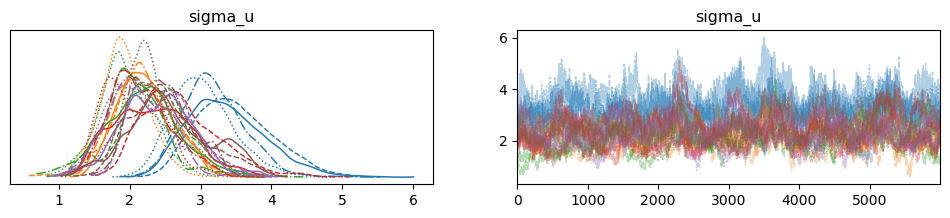

In [16]:
az.plot_trace(fit, var_names=["sigma_u"])

`beta`は枠の良し悪しなので、一般的に言われているように1コース圧倒的有利で、インに近いほど有利がきれいに結果として現れている。

In [17]:
az.summary(fit, var_names=["beta"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],3.06,0.39,2.37,3.79,0.09,0.02,23.73,178.72,1.15
beta[1],0.69,0.10,0.51,0.88,0.02,0.01,28.36,149.14,1.13
beta[2],-0.30,0.05,-0.41,-0.21,0.01,0.00,56.97,211.99,1.06
beta[3],-0.74,0.10,-0.94,-0.56,0.02,0.01,28.28,165.25,1.13
beta[4],-1.12,0.15,-1.41,-0.86,0.03,0.01,24.58,142.84,1.15
beta[5],-1.58,0.21,-2.00,-1.23,0.05,0.01,23.95,170.51,1.15


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

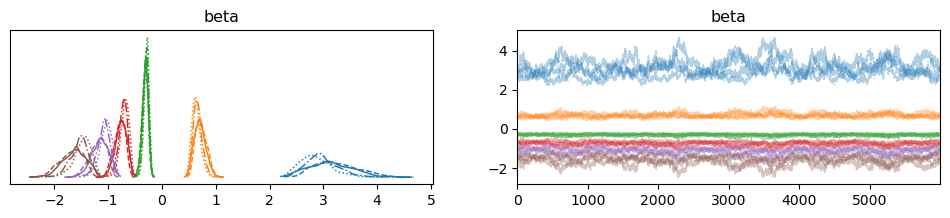

In [18]:
az.plot_trace(fit, var_names=["beta"])

相関構造（展開）の`Omega`をみる。

In [19]:
az.summary(fit, var_names=["Omega"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"Omega[0, 0]",1.00,0.00,1.00,1.00,0.00,NaN,24000.00,24000.00,NaN
"Omega[0, 1]",0.08,0.16,-0.22,0.36,0.01,0.01,171.54,415.53,1.03
"Omega[0, 2]",0.07,0.15,-0.22,0.35,0.01,0.00,371.96,881.26,1.02
"Omega[0, 3]",-0.03,0.15,-0.33,0.24,0.02,0.00,68.12,476.03,1.04
"Omega[0, 4]",-0.12,0.15,-0.40,0.17,0.02,0.01,103.23,340.46,1.03
"Omega[0, 5]",-0.12,0.14,-0.39,0.15,0.02,0.00,79.37,771.90,1.06
"Omega[1, 0]",0.08,0.16,-0.22,0.36,0.01,0.01,171.54,415.53,1.03
"Omega[1, 1]",1.00,0.00,1.00,1.00,0.00,NaN,24000.00,24000.00,NaN
"Omega[1, 2]",0.00,0.18,-0.34,0.34,0.02,0.01,135.13,368.07,1.04
"Omega[1, 3]",-0.05,0.17,-0.38,0.26,0.02,0.01,65.02,245.74,1.06


/Users/aki/miniforge3/envs/ts/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


array([[<Axes: title={'center': 'Omega'}>,
        <Axes: title={'center': 'Omega'}>]], dtype=object)

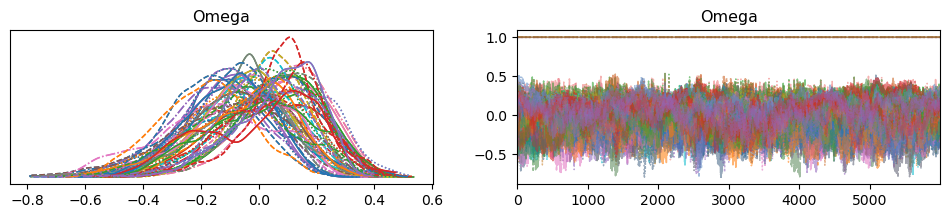

In [20]:
az.plot_trace(fit, var_names=["Omega"])

そこまでわかりやすく展開が相関の数値として現れているわけではないが、傾向としては「内枠がでれば、外枠は沈む」「外枠がでれば、内枠は沈む」というよく見る展開が可視化されている。`lkj_corr_cholesky(4);`を調整することで、この部分の強弱も変更できる。

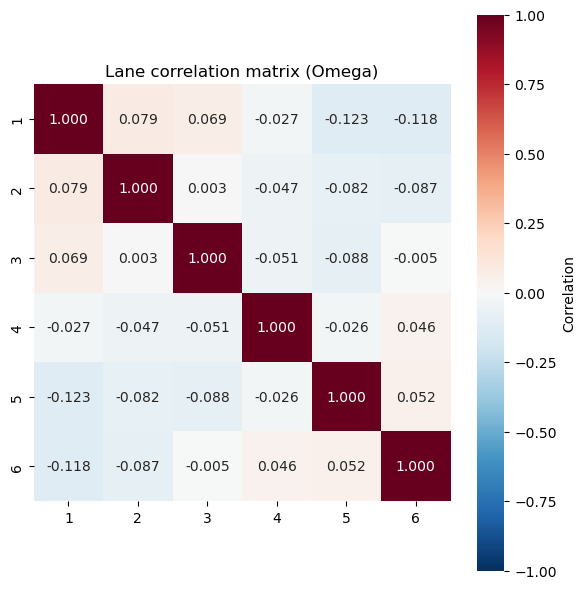

In [ ]:
import pandas as pd

Omega_draws = fit.stan_variable("Omega")
Omega_mean = Omega_draws.mean(axis=0)
df_omega = pd.DataFrame(Omega_mean, index=range(1, 7), columns=range(1, 7))
plt.figure(figsize=(6, 6))
sns.heatmap(
    df_omega,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Lane correlation matrix (Omega)")
plt.tight_layout()
plt.show()